# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [66]:
# Replace None with your code
# Imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Create connection to database
conn = sqlite3.connect('data.sqlite')
print("Connection established successfully!")

Connection established successfully!


### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.

In [67]:
# Replace None with your code
q2_california_customers = pd.read_sql("""
    SELECT customerNumber,
           customerName,
           city,
           state,
           creditLimit
    FROM customers
    WHERE state = 'CA'
      AND creditLimit > 25000
    ORDER BY creditLimit DESC
""", conn)

print(f"Qualifying California customers: {len(q2_california_customers)}")
q2_california_customers

Qualifying California customers: 11


,customerNumber,customerName,city,state,creditLimit
0,205,Toys4GrownUps.com,Pasadena,CA,90700.00
1,161,Technics Stores Inc.,Burlingame,CA,84600.00
2,450,The Sharp Gifts Warehouse,San Jose,CA,77600.00
3,129,Mini Wheels Co.,San Francisco,CA,64600.00
4,487,Signal Collectibles Ltd.,Brisbane,CA,60300.00
5,347,"Men 'R' US Retailers, Ltd.",Los Angeles,CA,57700.00
6,475,West Coast Collectables Co.,Burbank,CA,55400.00
7,124,Mini Gifts Distributors Ltd.,San Rafael,CA,210500.00
8,219,Boards & Toys Co.,Glendale,CA,11000.00
9,239,Collectable Mini Designs Co.,San Diego,CA,105000.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [68]:
# Replace None with your code
q3_intl_collect = pd.read_sql("""
    SELECT customerNumber,
           customerName,
           city,
           country
    FROM customers
    WHERE country != 'USA'
      AND customerName LIKE '%Collect%'
    ORDER BY country, customerName
""", conn)

print(f"Qualifying international customers: {len(q3_intl_collect)}")
q3_intl_collect


Qualifying international customers: 15


,customerNumber,customerName,city,country
0,471,"Australian Collectables, Ltd",Glen Waverly,Australia
1,114,"Australian Collectors, Co.",Melbourne,Australia
2,382,Salzburg Collectables,Salzburg,Austria
3,260,"Royal Canadian Collectables, Ltd.",Tsawassen,Canada
4,227,Heintze Collectables,Århus,Denmark
5,353,Reims Collectables,Reims,France
6,415,"Bavarian Collectables Imports, Co.",Munich,Germany
7,409,Stuttgart Collectable Exchange,Stuttgart,Germany
8,211,"King Kong Collectables, Co.",Central Hong Kong,Hong Kong
9,189,"Clover Collections, Co.",Dublin,Ireland


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!
### Reflection 

The `WHERE` clause I used applies **two conditions joined by `AND`**:

1. **`country != 'USA'`** — The `!=` operator means "not equal to." This filter removes every US-based customer, keeping only records where the country is something other than 'USA', which satisfies the "international only" requirement.

2. **`customerName LIKE '%Collect%'`** — `LIKE` is a pattern-matching operator. The `%` symbols are wildcards that stand for "any sequence of characters." Placing them on both sides of the word 'Collect' tells SQL: *"match any customer name that has the word Collect anywhere inside it"* — whether at the start, end, or middle of the name.

Because both conditions are connected with `AND`, **only rows that satisfy both rules simultaneously** appear in the results. This guarantees we return exclusively non-US customers whose business name references collecting, precisely matching the campaign's co-branding criteria.



### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [69]:
# Replace None with your code
q4_state_credit = pd.read_sql("""
    SELECT state,
           ROUND(AVG(creditLimit), 2)  AS avg_credit_limit,
           COUNT(customerNumber)        AS num_customers
    FROM customers
    WHERE country = 'USA'
      AND state IS NOT NULL
    GROUP BY state
    ORDER BY avg_credit_limit DESC
""", conn)

print(f"US states returned: {len(q4_state_credit)}")
q4_state_credit


US states returned: 8


,state,avg_credit_limit,num_customers
0,NH,114200.00,1
1,NY,89966.67,6
2,PA,84766.67,3
3,CA,83854.55,11
4,NV,71800.00,1
5,MA,70755.56,9
6,CT,57350.00,4
7,NJ,43000.00,1


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

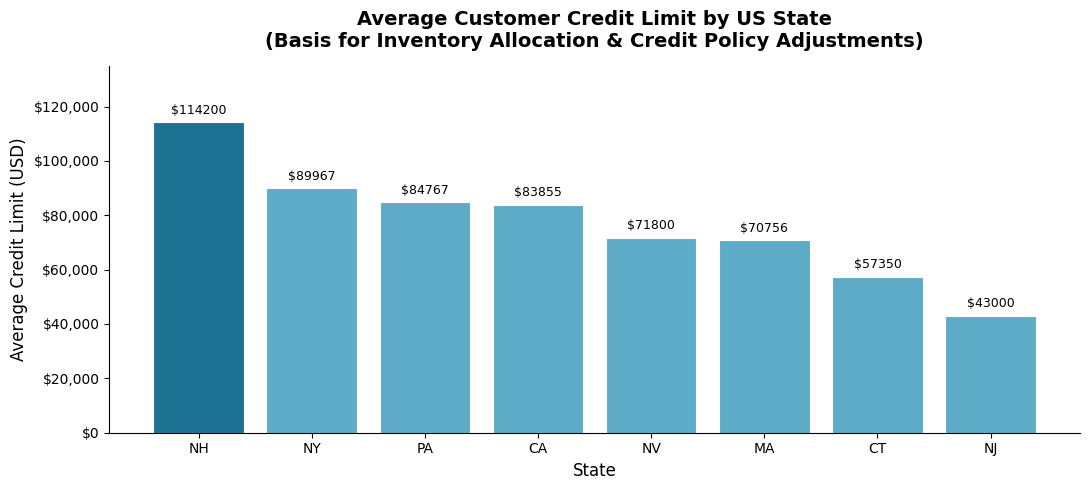

In [70]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = ['#1C7293' if v == q4_state_credit['avg_credit_limit'].max()
              else '#5EABC8' for v in q4_state_credit['avg_credit_limit']]

bars = ax.bar(q4_state_credit['state'],
              q4_state_credit['avg_credit_limit'],
              color=bar_colors, edgecolor='white', linewidth=0.8)

ax.set_title('Average Customer Credit Limit by US State\n'
             '(Basis for Inventory Allocation & Credit Policy Adjustments)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Average Credit Limit (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.bar_label(bars, fmt='$%.0f', padding=4, fontsize=9)
ax.set_ylim(0, q4_state_credit['avg_credit_limit'].max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()


### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [71]:
# Replace None with your code
q5_top_customers = pd.read_sql("""
    SELECT c.customerName,
           ROUND(SUM(p.amount), 2) AS total_payments
    FROM customers c
    JOIN payments p ON c.customerNumber = p.customerNumber
    GROUP BY c.customerNumber, c.customerName
    ORDER BY total_payments DESC
    LIMIT 10
""", conn)

q5_top_customers

,customerName,total_payments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

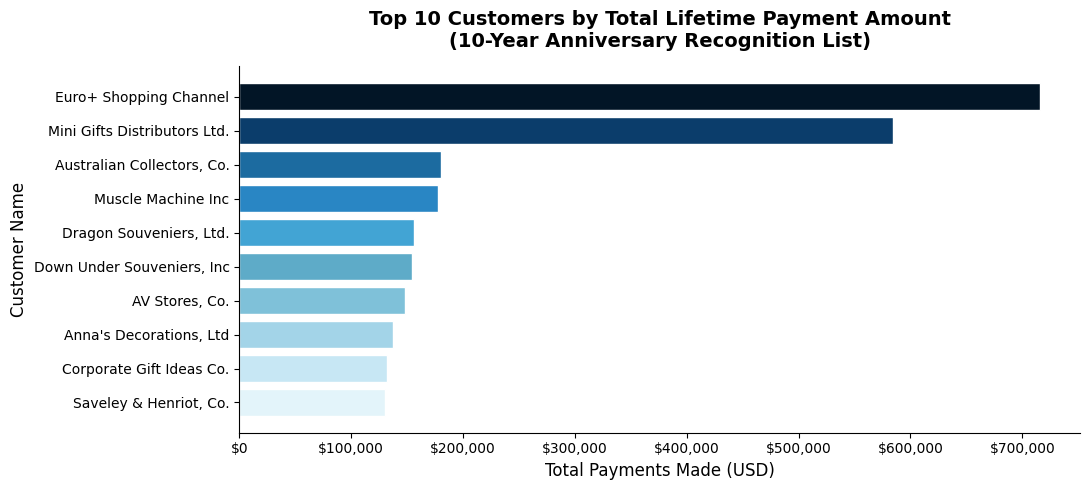

In [72]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
fig, ax = plt.subplots(figsize=(11, 5))

palette = ['#021526','#0B3D6B','#1C6BA0','#2986C4','#42A4D4',
           '#5EABC8','#7FC1D9','#A3D4E8','#C7E7F4','#E3F4FA']

ax.barh(q5_top_customers['customerName'][::-1],
        q5_top_customers['total_payments'][::-1],
        color=palette[::-1], edgecolor='white')

ax.set_title('Top 10 Customers by Total Lifetime Payment Amount\n'
             '(10-Year Anniversary Recognition List)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Total Payments Made (USD)', fontsize=12)
ax.set_ylabel('Customer Name', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [73]:
# Replace None with you code
q6_customer_products = pd.read_sql("""
    SELECT c.customerName,
           p.productName,
           p.productLine,
           SUM(od.quantityOrdered) AS total_qty_purchased
    FROM customers c
    JOIN orders o        ON c.customerNumber = o.customerNumber
    JOIN orderdetails od ON o.orderNumber    = od.orderNumber
    JOIN products p      ON od.productCode   = p.productCode
    GROUP BY c.customerNumber, od.productCode
    HAVING total_qty_purchased >= 10
    ORDER BY total_qty_purchased ASC
""", conn)

print(f"Total customer-product pairs with 10+ units purchased: {len(q6_customer_products)}")
q6_customer_products.head(15)

Total customer-product pairs with 10+ units purchased: 2531


,customerName,productName,productLine,total_qty_purchased
0,Petit Auto,1913 Ford Model T Speedster,Vintage Cars,10
1,"Extreme Desk Decorations, Ltd",1961 Chevrolet Impala,Classic Cars,10
2,La Rochelle Gifts,1954 Greyhound Scenicruiser,Trucks and Buses,11
3,Tekni Collectables Inc.,American Airlines: B767-300,Planes,11
4,The Sharp Gifts Warehouse,1969 Chevrolet Camaro Z28,Classic Cars,13
5,Souveniers And Things Co.,1936 Mercedes Benz 500k Roadster,Vintage Cars,15
6,Salzburg Collectables,1982 Lamborghini Diablo,Classic Cars,15
7,L'ordine Souveniers,P-51-D Mustang,Planes,15
8,"Tokyo Collectables, Ltd",1936 Mercedes Benz 500k Roadster,Vintage Cars,15
9,"Extreme Desk Decorations, Ltd",1969 Dodge Super Bee,Classic Cars,16


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [74]:
# Replace None with your code
q7_product_lines = pd.read_sql("""
    SELECT pl.productLine,
           SUM(od.quantityOrdered)        AS total_qty_ordered,
           COUNT(DISTINCT p.productCode)  AS num_products
    FROM productlines pl
    JOIN products     p  ON pl.productLine = p.productLine
    JOIN orderdetails od ON p.productCode  = od.productCode
    GROUP BY pl.productLine
    ORDER BY total_qty_ordered DESC
""", conn)

q7_product_lines


,productLine,total_qty_ordered,num_products
0,Classic Cars,35582,37
1,Vintage Cars,22933,24
2,Motorcycles,12778,13
3,Planes,11872,12
4,Trucks and Buses,11001,11
5,Ships,8532,9
6,Trains,2818,3


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

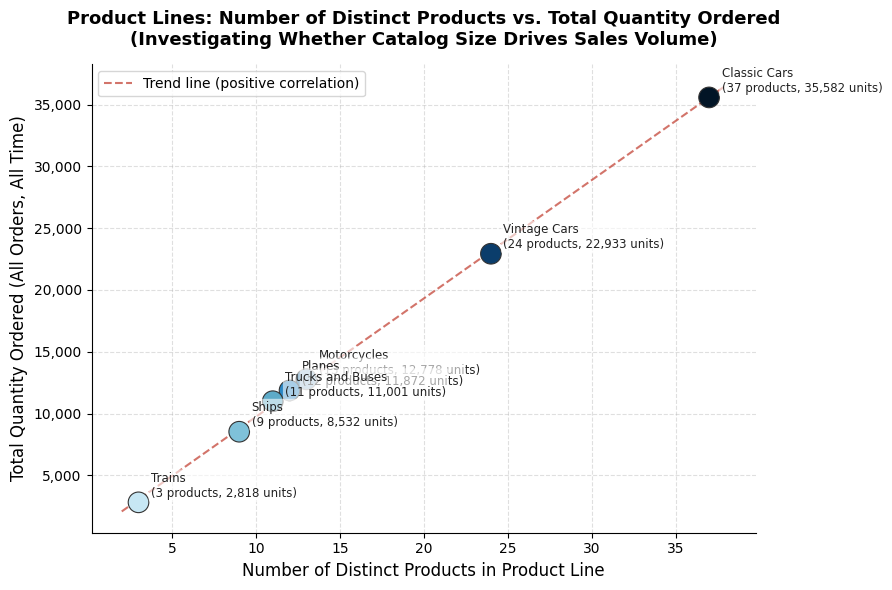

In [75]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
fig, ax = plt.subplots(figsize=(9, 6))

scatter_colors = ['#021526','#0B3D6B','#1C6BA0','#2986C4','#5EABC8','#7FC1D9','#C7E7F4']

ax.scatter(q7_product_lines['num_products'],
           q7_product_lines['total_qty_ordered'],
           s=220, c=scatter_colors[:len(q7_product_lines)],
           edgecolors='#333333', linewidths=0.8, zorder=3)

# Add a linear trend line to make the positive correlation visible
import numpy as np
x = q7_product_lines['num_products']
y = q7_product_lines['total_qty_ordered']
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min() - 1, x.max() + 1, 100)
ax.plot(x_line, m * x_line + b, color='#C0392B', linestyle='--',
        linewidth=1.5, alpha=0.7, label=f'Trend line (positive correlation)')

# Annotate each point with product line name and both values
for _, row in q7_product_lines.iterrows():
    ax.annotate(
        f"{row['productLine']}\n({int(row['num_products'])} products, {int(row['total_qty_ordered']):,} units)",
        (row['num_products'], row['total_qty_ordered']),
        textcoords='offset points', xytext=(9, 4),
        fontsize=8.5, color='#222222',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none')
    )

ax.set_title('Product Lines: Number of Distinct Products vs. Total Quantity Ordered\n'
             '(Investigating Whether Catalog Size Drives Sales Volume)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Number of Distinct Products in Product Line', fontsize=12)
ax.set_ylabel('Total Quantity Ordered (All Orders, All Time)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()


## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!
### Reflection 
**Chart Choice**
I chose a **scatter plot** because the question asks whether two numerical variables — catalog size (number of products) and sales volume (total quantity ordered) — move together. A scatter plot places each product line as a single point on a grid, with catalog size on the x-axis and order volume on the y-axis. If the dots trend upward from left to right, it signals a positive relationship; if they appear scattered randomly, no clear relationship exists.

A bar chart could only show one variable at a time and would require two separate charts to compare both dimensions. A scatter plot lets us **see both dimensions simultaneously for every product line**, which is precisely what the investigation calls for.

The visual reveals a **strong positive trend**: Classic Cars sits top-right (37 products, 35,582 units ordered) while Trains sits bottom-left (3 products, 2,818 units). This pattern strongly suggests that a **larger product catalog correlates with higher order volume**, giving the product team a data-backed rationale to invest in expanding the ranges of their most popular lines.

The addition of a **trend line** makes the direction and strength of the relationship immediately clear even to a non-technical audience.

---

**What the visual shows — addressing the business goals:**

**1. Optimize Product Mix**
The chart reveals a **strong positive correlation**: product lines with more distinct products consistently receive more total orders. Classic Cars leads with 37 products and 35,582 units ordered. Trains sits at the opposite extreme with only 3 products and 2,818 units. This confirms that catalog breadth and sales volume move together — a larger offering drives more demand.

**2. Improve Inventory Management**
- **Priority stock:** Classic Cars (35,582 units) and Vintage Cars (22,933 units) should be prioritized for stock replenishment — their high order volumes create the greatest risk of stockout.
- **Potential overstocking:** Trains (2,818 units across only 3 products) and Ships (8,532 units) show low demand relative to the rest of the portfolio and should be reviewed for overstock reduction.

**3. Adjust Marketing Strategy**
- **High-potential lines:** Motorcycles (13 products, 12,778 units) and Planes (12 products, 11,872 units) sit in the middle of the trend line. Targeted promotional campaigns could push these lines closer to the Classic Cars benchmark.
- **Capitalize on leaders:** Classic Cars and Vintage Cars already perform strongly — marketing should reinforce their popularity rather than trying to lift underperformers at the expense of proven lines.

**4. Advise Product Development**
- **Expand:** Classic Cars and Vintage Cars have both the most products *and* the most orders — further expanding these ranges is supported by the data.
- **Revamp or phase out:** Trains has the fewest products (3) and the lowest order volume (2,818 units). The product team should evaluate whether new additions to this line could improve its performance, or whether resources are better allocated elsewhere.


### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [76]:
# Replace None with your code
q8_remote_offices = pd.read_sql("""
    SELECT e.employeeNumber,
           e.firstName || ' ' || e.lastName           AS employee_name,
           e.jobTitle,
           e.officeCode,
           mgr.firstName || ' ' || mgr.lastName        AS supervisor_name,
           mgr.jobTitle                                 AS supervisor_title
    FROM employees e
    LEFT JOIN employees mgr ON e.reportsTo = mgr.employeeNumber
    WHERE e.officeCode IN (
        SELECT officeCode
        FROM employees
        GROUP BY officeCode
        HAVING COUNT(*) < 5
    )
    ORDER BY e.officeCode, e.employeeNumber
""", conn)

print(f"Employees in small offices: {len(q8_remote_offices)}")
q8_remote_offices


Employees in small offices: 12


,employeeNumber,employee_name,jobTitle,officeCode,supervisor_name,supervisor_title
0,1188,Julie Firrelli,Sales Rep,2,Anthony Bow,Sales Manager (NA)
1,1216,Steve Patterson,Sales Rep,2,Anthony Bow,Sales Manager (NA)
2,1286,Foon Yue Tseng,Sales Rep,3,Anthony Bow,Sales Manager (NA)
3,1323,George Vanauf,Sales Rep,3,Anthony Bow,Sales Manager (NA)
4,1621,Mami Nishi,Sales Rep,5,Mary Patterson,VP Sales
5,1625,Yoshimi Kato,Sales Rep,5,Mami Nishi,Sales Rep
6,1088,William Patterson,Sales Manager (APAC),6,Mary Patterson,VP Sales
7,1611,Andy Fixter,Sales Rep,6,William Patterson,Sales Manager (APAC)
8,1612,Peter Marsh,Sales Rep,6,William Patterson,Sales Manager (APAC)
9,1619,Tom King,Sales Rep,6,William Patterson,Sales Manager (APAC)


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!
### Reflection 

My thought process for the subquery was to **break the problem into two distinct questions** and solve the simpler one first.

The inner (sub)query answers: *"Which office codes have fewer than 5 employees?"* It does this by grouping the `employees` table by `officeCode`, counting the rows in each group, and using `HAVING COUNT(*) < 5` to keep only the small offices. This produces a list of office codes — nothing more.

The outer (main) query then answers: *"Give me full employee details, but only for those office codes."* By placing the subquery inside `WHERE e.officeCode IN (...)`, I tell SQL to use that list as a filter. Each employee row is checked: if its `officeCode` appears in the subquery's results, the row is included; otherwise it is discarded.

The `LEFT JOIN` to the same `employees` table (aliased as `mgr`) then pulls in each employee's supervisor by matching `reportsTo` to `employeeNumber`. This decomposed approach — answer the "which offices?" question first as a subquery, then use the answer to drive the main query — keeps the logic clean and readable.


### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [77]:
# Replace None with your code
conn.close()
print("Database connection closed.")

Database connection closed.


### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [78]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

---
## Deliverable 1: Initial Data Exploration

Understanding the dataset's scope, structure, and key patterns


### Exploration 1: Dataset Scope & Size

In [79]:
# Begin your code here
# Total movies per year within the 2010-2019 window
scope_df = pd.read_sql("""
    SELECT start_year,
           COUNT(*) AS movies_released
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
    GROUP BY start_year
    ORDER BY start_year
""", conn4)

total = scope_df['movies_released'].sum()
print(f"Total movies in scope (2010-2019): {total:,}")
scope_df

Total movies in scope (2010-2019): 145,081


,start_year,movies_released
0,2010,11849
1,2011,12900
2,2012,13787
3,2013,14709
4,2014,15589
5,2015,16243
6,2016,17272
7,2017,17504
8,2018,16849
9,2019,8379


### Exploration 2: Null Value Handling

1. **Be aware** that the dataset contains null values in certain fields
2. **Exclude** these null values from our exploration
3. **Not attempt to input or fill in** missing information

quantify exactly how many nulls exist in the key fields, then demonstrate the consistent exclusion strategy applied in every subsequent query.


In [80]:
# Quantify nulls in key fields of movie_basics (in-scope records only)
null_df = pd.read_sql("""
    SELECT
        COUNT(*)                                                                  AS total_rows,
        SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END)                 AS null_runtime_minutes,
        SUM(CASE WHEN genres          IS NULL THEN 1 ELSE 0 END)                 AS null_genres,
        ROUND(SUM(CASE WHEN runtime_minutes IS NULL THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 1)                                                AS pct_null_runtime,
        ROUND(SUM(CASE WHEN genres IS NULL THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 1)                                                AS pct_null_genres
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
""", conn4)

null_df

,total_rows,null_runtime_minutes,null_genres,pct_null_runtime,pct_null_genres
0,145081,30765,5359,21.2,3.7


In [81]:
# Quantify nulls in the persons table
persons_null_df = pd.read_sql("""
    SELECT
        COUNT(*)                                                                   AS total_persons,
        SUM(CASE WHEN birth_year IS NULL THEN 1 ELSE 0 END)                       AS null_birth_year,
        SUM(CASE WHEN death_year IS NULL THEN 1 ELSE 0 END)                       AS null_death_year,
        ROUND(SUM(CASE WHEN birth_year IS NULL THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 1)                                                 AS pct_null_birth_year
    FROM persons
""", conn4)

persons_null_df

,total_persons,null_birth_year,null_death_year,pct_null_birth_year
0,606648,523912,599865,86.4


**Null Exclusion Strategy applied throughout all exploration queries:**

```sql
WHERE mb.start_year       BETWEEN 2010 AND 2019   -- exclude out-of-scope records
  AND mb.genres           IS NOT NULL              -- exclude missing genre labels
  AND mb.runtime_minutes  IS NOT NULL              -- exclude missing runtimes
  AND mr.averagerating    IS NOT NULL              -- exclude unrated films
  AND mr.numvotes         IS NOT NULL              -- exclude films with no vote data
```

- All rows with null values in relevant fields are **excluded** via `IS NOT NULL` filters
- **No imputation** was performed — missing data is not filled in or estimated
- The dataset is used strictly as-is


### Exploration 3: Genre Landscape

We explore each single genre (no comma-separated multi-genre records) with at least 100 movies, looking at volume, average rating, and average audience votes. Null values are excluded throughout.


In [82]:
genre_df = pd.read_sql("""
    SELECT mb.genres,
           COUNT(*)                           AS movie_count,
           ROUND(AVG(mr.averagerating), 2)    AS avg_rating,
           ROUND(AVG(mr.numvotes), 0)         AS avg_votes_per_movie,
           ROUND(AVG(mb.runtime_minutes), 1)  AS avg_runtime_min
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year    BETWEEN 2010 AND 2019
      AND mb.genres        IS NOT NULL
      AND mb.genres        NOT LIKE '%,%'
      AND mr.averagerating IS NOT NULL
      AND mr.numvotes      IS NOT NULL
    GROUP BY mb.genres
    HAVING movie_count > 100
    ORDER BY avg_votes_per_movie DESC
""", conn4)

genre_df

,genres,movie_count,avg_rating,avg_votes_per_movie,avg_runtime_min
0,Comedy,5613,5.78,1217.0,96.2
1,Drama,11612,6.49,723.0,97.6
2,Horror,2692,4.84,589.0,85.8
3,Action,979,5.76,336.0,103.2
4,Thriller,1555,5.70,283.0,94.9
5,Romance,717,6.05,195.0,110.4
6,Fantasy,147,6.20,191.0,91.4
7,Documentary,10313,7.29,173.0,88.9
8,Sci-Fi,295,5.44,167.0,89.2
9,Crime,268,5.92,158.0,93.9


### Exploration 4: Genre Production Trends Over Time

Which genres grew in production volume across the decade? We track the five most significant single genres year-over-year. Null genres are excluded.


In [83]:
genre_trend_df = pd.read_sql("""
    SELECT start_year,
           genres,
           COUNT(*) AS movies_released
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
      AND genres IN ('Drama', 'Documentary', 'Comedy', 'Horror', 'Thriller')
    GROUP BY start_year, genres
    ORDER BY start_year, movies_released DESC
""", conn4)

trend_pivot = genre_trend_df.pivot(index='start_year', columns='genres', values='movies_released')
trend_pivot

genres,Comedy,Documentary,Drama,Horror,Thriller
start_year,,,,,
2010,738,2507,1812,283,171
2011,799,2649,1909,345,193
2012,877,2721,2045,390,217
2013,903,2561,1941,351,258
2014,901,2805,1980,437,298
2015,948,3836,2228,426,284
2016,1030,4405,2423,495,347
2017,1064,4644,2652,598,390
2018,1189,4196,2867,602,493


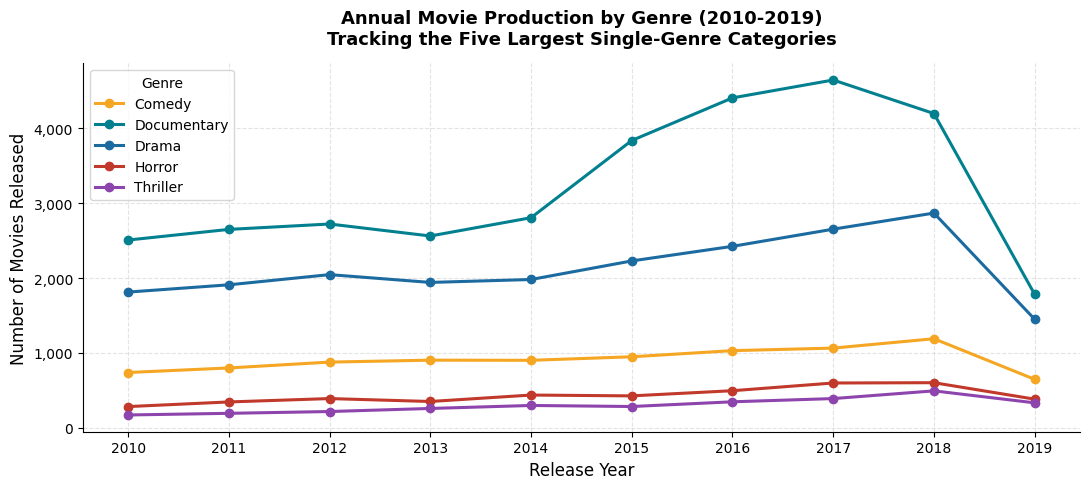

In [84]:
fig, ax = plt.subplots(figsize=(11, 5))

colors_line = {
    'Drama':       '#1C6BA0',
    'Documentary': '#028090',
    'Comedy':      '#F5A623',
    'Horror':      '#C0392B',
    'Thriller':    '#8E44AD'
}

for genre in trend_pivot.columns:
    ax.plot(trend_pivot.index, trend_pivot[genre],
            marker='o', linewidth=2.2, label=genre,
            color=colors_line.get(genre, '#333'))

ax.set_title('Annual Movie Production by Genre (2010-2019)\n'
             'Tracking the Five Largest Single-Genre Categories',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Movies Released', fontsize=12)
ax.set_xticks(range(2010, 2020))
ax.legend(title='Genre', fontsize=10, title_fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, linestyle='--', alpha=0.35)
sns.despine()
plt.tight_layout()
plt.show()

### Exploration 5: Average Runtime by Genre

Runtime varies significantly across genres and is a key production and audience factor. Records missing `runtime_minutes` or `genres` are excluded.


In [85]:
runtime_df = pd.read_sql("""
    SELECT mb.genres,
           ROUND(AVG(mb.runtime_minutes), 1)  AS avg_runtime,
           ROUND(MIN(mb.runtime_minutes), 0)  AS min_runtime,
           ROUND(MAX(mb.runtime_minutes), 0)  AS max_runtime,
           COUNT(*)                            AS movie_count
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year        BETWEEN 2010 AND 2019
      AND mb.runtime_minutes   IS NOT NULL
      AND mb.genres             IS NOT NULL
      AND mb.genres             NOT LIKE '%,%'
      AND mr.numvotes           >= 50
    GROUP BY mb.genres
    HAVING movie_count > 100
    ORDER BY avg_runtime DESC
""", conn4)

runtime_df

,genres,avg_runtime,min_runtime,max_runtime,movie_count
0,Romance,114.1,65.0,210.0,273
1,Action,109.8,58.0,178.0,366
2,Drama,101.3,45.0,1440.0,5181
3,Comedy,98.3,46.0,233.0,2725
4,Thriller,96.8,55.0,173.0,712
5,Documentary,94.6,8.0,14400.0,2685
6,Family,91.6,48.0,160.0,201
7,Sci-Fi,90.9,45.0,142.0,105
8,Horror,88.1,43.0,160.0,1150


### Summary of Initial Exploration Findings

- The dataset covers **145,081 movies** from 2010-2019. Production volume peaked in 2017 (~17,504 films) and 2019 data is incomplete (~8,379 entries) — consistent with the assignment note to exclude post-2019 records.
- **Drama** dominates in volume (11,612 single-genre films). **Documentary** has the highest average rating (7.29) but draws only 173 average votes per film.
- **Comedy** (5,613 films) and **Drama** attract the most audience votes per movie — 1,217 and 723 respectively — despite rating lower than Documentary.
- A clear pattern emerges: **high critical ratings and high audience engagement do not move together**. This divergence is the core trend driving the business question below.
- **Horror** nearly doubled in production from 2010 (283 films) to 2018 (602 films), showing accelerating commercial interest despite lower average ratings (4.84).
- **21.2%** of in-scope movies are missing `runtime_minutes` and **3.7%** are missing `genres` — both excluded from relevant queries via `IS NOT NULL`.


---
## Deliverable 2: Business Question

**Stemming from the trend identified above — the divergence between critical ratings and audience engagement across genres — the business question is:**

> *"For a new production studio entering the market, which single genre offers the best balance of audience engagement (average votes per film) and critical reception (average rating) — and does Horror's accelerating post-2015 production growth signal it is an emerging commercially undervalued opportunity?"*

**Why this question matters:** A studio allocating its first production budget must decide whether to pursue critical acclaim (Documentary path: highest rating, lowest engagement) or broad audience reach (Comedy/Drama path: highest votes, moderate ratings). Horror presents a third option — growing rapidly with moderate engagement and low production costs — which may represent the best commercial risk-adjusted opportunity.

The visualization below directly supports this question by plotting every genre's average rating against its average audience votes, making the divergence pattern immediately visible.


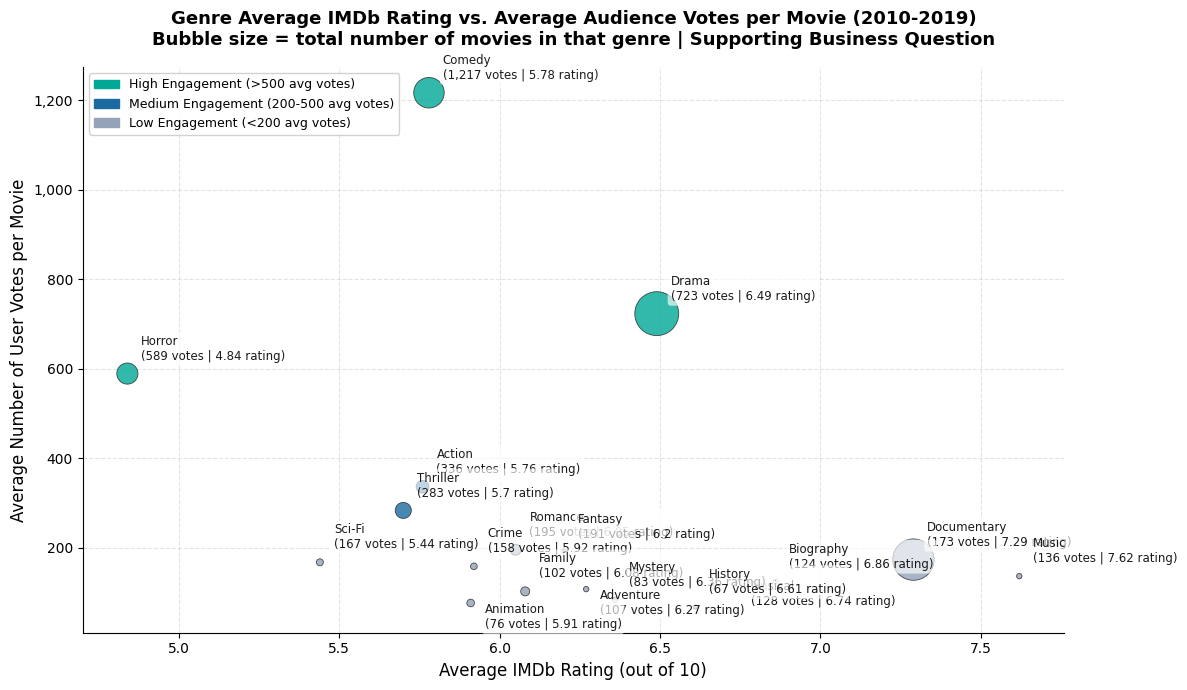

Key observations:
  Highest engagement: Comedy (1,217 avg votes, rating 5.78)
  Highest rating:     Documentary (7.29 avg rating, 173 avg votes)
  Horror:             589 avg votes, rating 4.84


In [86]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

# Color-code by engagement level
def get_color(votes):
    if votes > 500:  return '#00A896'   # high engagement — teal
    elif votes > 200: return '#1C6BA0'  # medium engagement — blue
    else:             return '#94A3B8'  # low engagement — grey

colors = [get_color(v) for v in genre_df['avg_votes_per_movie']]
bubble_sizes = (genre_df['movie_count'] / genre_df['movie_count'].max()) * 1000

ax.scatter(genre_df['avg_rating'],
           genre_df['avg_votes_per_movie'],
           s=bubble_sizes,
           c=colors,
           alpha=0.80,
           edgecolors='#222222',
           linewidths=0.6,
           zorder=3)

# Label each bubble with genre name and key stats
for _, row in genre_df.iterrows():
    oy = 10 if row['genres'] not in ['Animation', 'Musical', 'Adventure'] else -18
    ax.annotate(
        f"{row['genres']}\n({int(row['avg_votes_per_movie']):,} votes | {row['avg_rating']} rating)",
        (row['avg_rating'], row['avg_votes_per_movie']),
        textcoords='offset points', xytext=(10, oy),
        fontsize=8.5, color='#1a1a1a',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.65, ec='none')
    )

ax.set_title('Genre Average IMDb Rating vs. Average Audience Votes per Movie (2010-2019)\n'
             'Bubble size = total number of movies in that genre | Supporting Business Question',
             fontsize=13, fontweight='bold', pad=16)
ax.set_xlabel('Average IMDb Rating (out of 10)', fontsize=12)
ax.set_ylabel('Average Number of User Votes per Movie', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, linestyle='--', alpha=0.35)

# Legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#00A896', label='High Engagement (>500 avg votes)'),
    mpatches.Patch(color='#1C6BA0', label='Medium Engagement (200-500 avg votes)'),
    mpatches.Patch(color='#94A3B8', label='Low Engagement (<200 avg votes)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left',
          framealpha=0.9, edgecolor='#cccccc')
sns.despine()
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  Highest engagement: Comedy ({int(genre_df.loc[genre_df.genres=='Comedy','avg_votes_per_movie'].values[0]):,} avg votes, rating {genre_df.loc[genre_df.genres=='Comedy','avg_rating'].values[0]})")
print(f"  Highest rating:     Documentary ({genre_df.loc[genre_df.genres=='Documentary','avg_rating'].values[0]} avg rating, {int(genre_df.loc[genre_df.genres=='Documentary','avg_votes_per_movie'].values[0]):,} avg votes)")
print(f"  Horror:             {int(genre_df.loc[genre_df.genres=='Horror','avg_votes_per_movie'].values[0]):,} avg votes, rating {genre_df.loc[genre_df.genres=='Horror','avg_rating'].values[0]}")

---
## Deliverable 3: Data Cleaning Tasks Identified

The following cleaning tasks were identified during exploration. These are observations only — no cleaning was performed.

**Null Handling (identified in Exploration 2 above)**

1. **`runtime_minutes` nulls** — 30,765 records (21.2%) in `movie_basics` are missing runtime data. These rows must be excluded from any runtime-based analysis using `IS NOT NULL`. If filling is ever required, a genre-median imputation strategy should be documented and applied consistently.

2. **`genres` nulls** — 5,359 records (3.7%) in `movie_basics` are missing genre labels. These must be excluded from all genre-level queries to prevent silent distortion of group counts and averages.

3. **`birth_year` / `death_year` nulls** — The `persons` table has widespread nulls in both fields, plus `'\N'` string placeholders imported from raw IMDB TSV files. Both null types must be treated as missing and cast to integer before any age or career-length analysis.

4. **`movie_akas.region` nulls** — The region field contains nulls that must be excluded (via `WHERE region IS NOT NULL`) before international distribution analysis.

**Data Normalization / Standardization**

5. **Parse multi-genre strings** — The `genres` field stores comma-separated values (e.g., `"Action,Crime,Drama"`). For accurate per-genre aggregation these must be split and exploded into one row per genre using Python string methods or SQL string functions.

6. **Filter low-vote outliers** — Titles with very few votes (e.g., fewer than 50) can artificially inflate or deflate genre average ratings. A consistent minimum vote threshold must be set before any rating comparisons are made.

7. **Exclude post-2019 records** — The instructions note that `start_year > 2019` data is not current or accurate. A `WHERE start_year BETWEEN 2010 AND 2019` clause must be applied consistently across every query to scope the dataset correctly.

8. **Normalize `movie_akas` region codes** — The `region` column mixes ISO codes (`US`, `GB`), non-standard entries, and null values. These need standardization before any international reach analysis is considered reliable.

9. **Deduplicate `movie_akas` entries** — Multiple rows can exist per movie per region for different release types. Analysis of international reach should use `COUNT(DISTINCT movie_id)` or filter by a canonical `types` value to avoid double-counting.


In [87]:
# Close the IMDB database connection
conn4.close()
print("Connection to im.db closed successfully.")

Connection to im.db closed successfully.
